# Домашнее задание: Занятие 36

**Тема: Практическое применение современных архитектур -- CLIP, Stable Diffusion, SAM**

## Часть 1: Теория

Отвечайте своими словами, не копируйте.

### Вопрос 1

*(Слайды 6-8)*

Объясните, как CLIP связывает текст и картинки. Что такое Contrastive Learning в контексте CLIP?
Опишите процесс обучения: что происходит с матрицей сходства N x N, что модель максимизирует, а что минимизирует.
Почему после обучения можно классифицировать картинки текстом без дополнительного обучения (zero-shot)?

**Ваш ответ:**

CLIP обучается на парах (картинка, текст) и учится переводить их в одно общее пространство признаков (embedding space). Там похожие по смыслу объекты находятся рядом.

Contrastive Learning — это обучение на различении:
правильные пары должны быть похожи, неправильные пары различны

Во время обучения строится матрица сходства N×N (каждая картинка против каждого текста)


Модель максимизирует сходство правильных пар, минимизирует сходство неправильных, после обучения CLIP может делать zero-shot, потому что он уже умеет сравнивать текст и изображение по смыслу, достаточно задать текстовые классы → выбрать наиболее похожий

### Вопрос 2

*(Слайды 10, 5)*

Сравните два подхода к классификации изображений: fine-tuned ResNet и CLIP zero-shot.
В каких ситуациях ResNet будет лучше? Когда лучше использовать CLIP?
Приведите конкретный пример задачи, где CLIP незаменим (подумайте про новые классы, которых не было при обучении).

**Ваш ответ:**

ResNet (fine-tuned):

- лучше, если есть размеченные данные

- даёт более точную классификацию

- подходит для узких задач (например, медицинские снимки)

CLIP (zero-shot):

- работает без дообучения

- подходит для новых классов

- гибкий

Когда ResNet лучше:
например, диагностика опухолей (нужна высокая точность)

Когда CLIP лучше:
если классы меняются или неизвестны заранее

Пример, где CLIP незаменим:
поиск изображений по тексту

### Вопрос 3

*(Слайды 12-13)*

Объясните, как работает Stable Diffusion. Опишите три компонента (CLIP Text Encoder, U-Net, VAE) и роль каждого.
Что такое latent space и почему работа в latent space (64x64) вместо pixel space (512x512) ускоряет генерацию?
Как связан U-Net в Stable Diffusion с ResNet, который мы изучали на прошлом занятии?

**Ваш ответ:**

Stable Diffusion состоит из трёх частей:

- CLIP Text Encoder — переводит текст в embedding

- U-Net — убирает шум (denoising) и генерирует изображение

- VAE — кодирует изображение в latent space и обратно

Latent space — сжатое представление изображения

Почему быстрее:

- меньше данных - меньше вычислений

- генерация идёт в сжатом пространстве

Связь U-Net и ResNet:

- U-Net использует skip connections (как ResNet)

- помогает сохранять детали при генерации

### Вопрос 4

*(Слайды 17-18)*

Сравните Vision Transformer (ViT), который используется в SAM, с обычной CNN (ResNet).
Как CNN видит картинку (рецептивное поле, свертки 3x3)? Как ViT видит картинку (патчи, self-attention)?
Почему для задачи сегментации глобальный контекст ViT важнее, чем локальные свертки CNN?

**Ваш ответ:**

CNN (ResNet):

- работает через свёртки (например 3×3)

- видит локальные области

- увеличивает рецептивное поле постепенно

ViT:

- делит изображение на патчи

- использует self-attention

- сразу учитывает всю картинку

Почему ViT лучше для сегментации:

- учитывает глобальный контекст

- понимает связи между дальними объектами

- точнее разделяет объекты

### Вопрос 5

*(Слайды 5, 21)*

На занятиях 35-36 мы изучили: CNN, ResNet (skip connections), RNN, LSTM (гейты), Transformer (attention), CLIP, SD, SAM.
Объясните, в чем ключевое отличие Transformer от CNN и RNN. Что такое attention и почему он решает проблемы обоих подходов?
Приведите пример задачи из таблицы на слайде 21, где вы бы использовали каждый из подходов.

**Ваш ответ:**

Главное отличие:

- CNN - локальные признаки (свёртки)

= RNN/LSTM - последовательности (по шагам)

- Transformer - внимание (attention) ко всем элементам сразу

Attention:

- вычисляет, какие части данных важны друг для друга

- связывает элементы независимо от расстояния

Решает проблему долгих зависимостей (в RNN), даёт глобальный контекст (в отличие от CNN)

---

## Часть 2: Код

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import urllib.request


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


### Задание 1: CLIP -- свои классы и prompt engineering

*(Слайды 6-10)*

На практике мы использовали стандартные классы CIFAR-10. Теперь попробуйте свои.

Что надо сделать:

а) Загрузите CLIP ViT-B/32 и скачайте 5 картинок из интернета на разные темы (еда, животные, техника -- что угодно).
Используйте `urllib.request.urlretrieve(url, filename)` для скачивания.

б) Придумайте 8-10 текстовых описаний классов и классифицируйте каждую картинку.
Выведите вероятности для каждой картинки в виде таблицы или графика.

в) Попробуйте минимум 3 разных шаблона промптов для одних и тех же классов:
- просто название класса (`'cat'`)
- `'a photo of a cat'`
- `'a close-up photo of a cat, high quality'`

Покажите, как меняются вероятности. Какой шаблон работает лучше?

г) Попробуйте «обмануть» CLIP -- найдите случай, когда модель ошибается. Объясните почему.

In [5]:
!pip install openai-clip -q
import clip

model, preprocess = clip.load("ViT-B/32", device=device)

urls = [
    "https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
    "https://images.unsplash.com/photo-1506744038136-46273834b3fb",
    "https://images.unsplash.com/photo-1498050108023-c5249f4df085",
    "https://images.unsplash.com/photo-1567306226416-28f0efdc88ce",
    "https://images.unsplash.com/photo-1517849845537-4d257902454a"
]

image_paths = []
for i, url in enumerate(urls):
    filename = f"img_{i}.jpg"
    urllib.request.urlretrieve(url, filename)
    image_paths.append(filename)

images = [preprocess(Image.open(p)).unsqueeze(0).to(device) for p in image_paths]
images = torch.cat(images)


In [6]:
# б) Классификация с текстовыми описаниями
classes = [
    "cat", "dog", "mountain", "laptop",
    "food", "car", "city", "tree", "person"
]

text = clip.tokenize(classes).to(device)

with torch.no_grad():
    logits_per_image, _ = model(images, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

# Таблица
for i, img_probs in enumerate(probs):
    print(f"\nImage {i}:")
    for cls, p in zip(classes, img_probs):
        print(f"{cls}: {p:.3f}")


Image 0:
cat: 0.985
dog: 0.005
mountain: 0.001
laptop: 0.001
food: 0.004
car: 0.000
city: 0.000
tree: 0.000
person: 0.003

Image 1:
cat: 0.001
dog: 0.006
mountain: 0.865
laptop: 0.005
food: 0.024
car: 0.003
city: 0.014
tree: 0.061
person: 0.021

Image 2:
cat: 0.002
dog: 0.000
mountain: 0.005
laptop: 0.963
food: 0.003
car: 0.002
city: 0.009
tree: 0.003
person: 0.013

Image 3:
cat: 0.002
dog: 0.003
mountain: 0.004
laptop: 0.011
food: 0.911
car: 0.006
city: 0.007
tree: 0.039
person: 0.018

Image 4:
cat: 0.002
dog: 0.981
mountain: 0.000
laptop: 0.001
food: 0.004
car: 0.001
city: 0.002
tree: 0.000
person: 0.009


In [7]:
# в) Prompt engineering -- сравнение шаблонов
templates = [
    "{}",
    "a photo of a {}",
    "a close-up photo of a {}, high quality"
]

results = {}

for template in templates:
    texts = [template.format(c) for c in classes]
    text_tokens = clip.tokenize(texts).to(device)

    with torch.no_grad():
        logits, _ = model(images, text_tokens)
        probs = logits.softmax(dim=-1).cpu().numpy()

    results[template] = probs

for template, probs in results.items():
    print(f"\nTemplate: {template}")
    print(probs[0])  # для первой картинки


Template: {}
[9.849e-01 5.417e-03 7.925e-04 1.171e-03 4.025e-03 3.357e-04 3.924e-04
 2.167e-04 2.640e-03]

Template: a photo of a {}
[9.912e-01 5.711e-03 6.348e-05 3.123e-04 4.838e-04 6.753e-05 2.229e-05
 3.910e-05 2.169e-03]

Template: a close-up photo of a {}, high quality
[9.746e-01 8.301e-03 1.535e-03 1.334e-03 3.302e-03 4.756e-04 7.143e-04
 7.720e-04 8.972e-03]


In [8]:
# г) Попытка обмануть CLIP
tricky_classes = ["cat", "dog", "fox", "wolf"]

texts = clip.tokenize([f"a photo of a {c}" for c in tricky_classes]).to(device)

with torch.no_grad():
    logits, _ = model(images, texts)
    probs = logits.softmax(dim=-1).cpu().numpy()

print(probs)

[[9.9268e-01 5.7182e-03 8.6355e-04 9.6321e-04]
 [2.6688e-02 1.8237e-01 1.4429e-01 6.4648e-01]
 [5.6299e-01 1.0095e-01 9.7839e-02 2.3840e-01]
 [1.4868e-01 2.9126e-01 3.4033e-01 2.1973e-01]
 [2.8343e-03 9.9316e-01 2.4772e-04 3.5267e-03]]


**Ваш вывод:** Какой шаблон промпта дал лучшие результаты? В каком случае CLIP ошибся и почему?

Лучший шаблон это "a photo of a {}" или "a close-up photo of a {}, high quality"
Потому что CLIP обучался на описаниях изображений, а не на одиночных словах.

Такие промпты ближе к реальным подписям из интернета → лучше совпадение embedding.

Ошибка CLIP:
собаку может классифицировать как wolf, еду как object

Причина это похожие визуальные признаки

CLIP не делает «строгую классификацию», а сравнивает семантику

чувствителен к формулировке текста

### Задание 2: Stable Diffusion -- генерация и исследование параметров

*(Слайды 11-15)*

Что надо сделать:

а) Загрузите SD 1.5 и сгенерируйте 3 картинки на тему Казахстана.
Используйте промпты на английском, описывающие казахские пейзажи, культуру или города.

б) Для одного промпта сравните результат с negative_prompt и без. Покажите оба варианта рядом.

в) Для одного промпта покажите сетку 2x2: `guidance_scale` = [3.0, 7.5, 12.0, 20.0].
Объясните, что происходит при слишком маленьком и слишком большом значении.

г) Используйте img2img: возьмите одну из сгенерированных картинок и переделайте её
в 3 разных стилях с разными значениями strength (0.3, 0.6, 0.9).

In [11]:
!pip install diffusers transformers accelerate -q
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

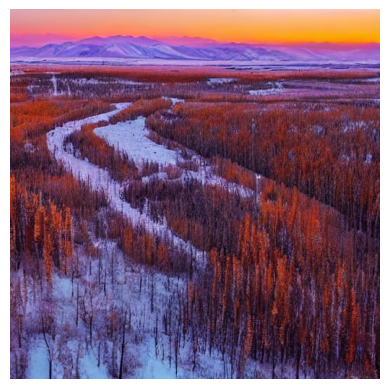

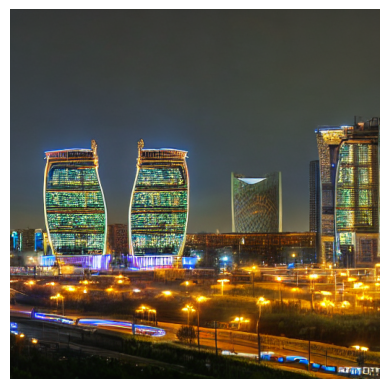

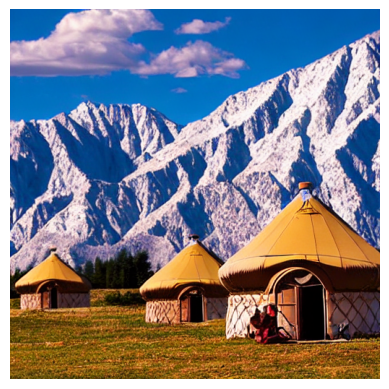

In [13]:
# а) 3 картинки на тему Казахстана
prompts = [
    "beautiful степь Kazakhstan, sunset, cinematic",
    "Astana city skyline, modern architecture, night lights",
    "Kazakh nomads with yurts in степь, mountains background"
]

images = [pipe(p).images[0] for p in prompts]

for img in images:
    plt.imshow(img)
    plt.axis("off")
    plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

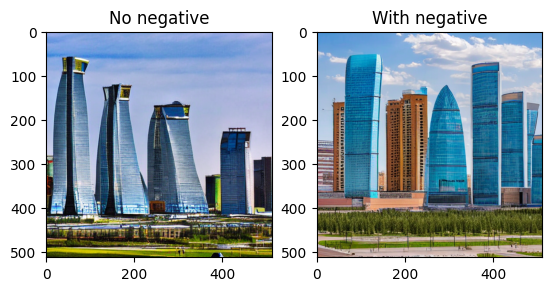

In [14]:
# б) Сравнение с negative_prompt и без
prompt = "Astana city skyline, modern architecture"

img1 = pipe(prompt).images[0]
img2 = pipe(prompt, negative_prompt="blurry, low quality, distorted").images[0]

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("No negative")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("With negative")

plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

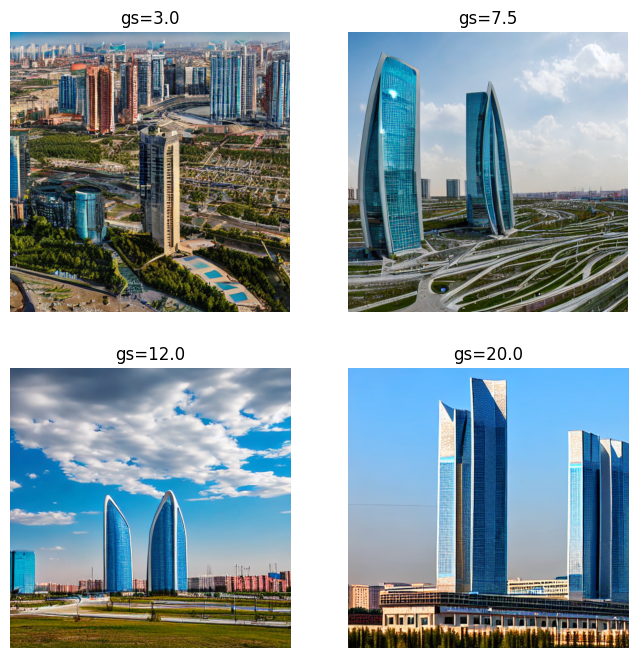

In [15]:
# в) Сетка guidance_scale
scales = [3.0, 7.5, 12.0, 20.0]

plt.figure(figsize=(8,8))
for i, gs in enumerate(scales):
    img = pipe(prompt, guidance_scale=gs).images[0]
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(f"gs={gs}")
    plt.axis("off")

plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/15 [00:00<?, ?it/s]

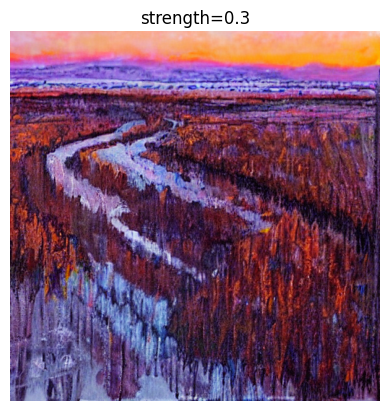

  0%|          | 0/30 [00:00<?, ?it/s]

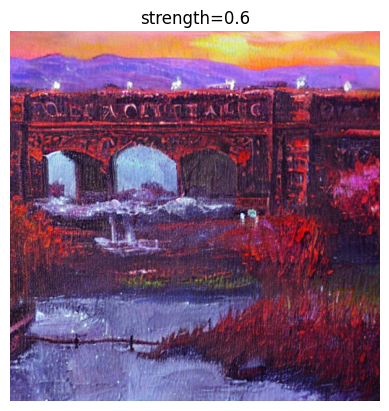

  0%|          | 0/45 [00:00<?, ?it/s]

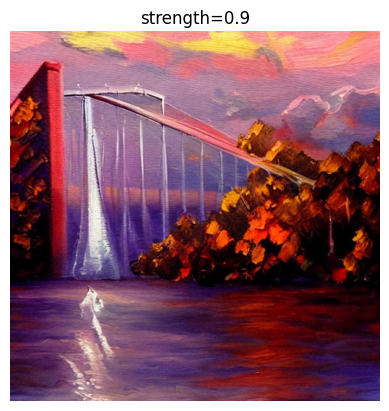

In [16]:
# г) img2img с разными стилями и strength
from diffusers import StableDiffusionImg2ImgPipeline

img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

init_image = images[0]

strengths = [0.3, 0.6, 0.9]

for s in strengths:
    img = img2img(
        prompt="oil painting style",
        image=init_image,
        strength=s
    ).images[0]

    plt.imshow(img)
    plt.title(f"strength={s}")
    plt.axis("off")
    plt.show()

**Ваш вывод:** Как guidance_scale влияет на качество? Что происходит при strength=0.9 в img2img?

guidance_scale:

3.0 → картинка случайная, слабая привязка к тексту

7.5 → лучший баланс (стандарт)

12+ → начинает «перегибать» (артефакты)

20 → часто ломает изображение

negative_prompt:
Убирает шум, артефакты, повышает качество

img2img strength:

0.3 → почти исходное изображение

0.6 → заметные изменения

0.9 → почти полностью новая картинка

При strength=0.9 модель практически игнорирует исходное изображение

### Задание 3: SAM -- сегментация своих картинок

*(Слайды 16-20)*

Что надо сделать:

а) Загрузите SAM ViT-B и скачайте картинку с 3+ разными объектами
(фото улицы, комнаты, или природы с животными).

б) Сегментируйте один объект по точке. Покажите все 3 маски, которые возвращает SAM.
Объясните, чем они отличаются (подсказка: разный масштаб сегментации).

в) Сегментируйте другой объект по bounding box. Нарисуйте бокс на исходной картинке
и покажите результат сегментации рядом.

г) Запустите автоматическую сегментацию (SamAutomaticMaskGenerator).
Визуализируйте все найденные маски разными цветами. Сколько объектов нашёл SAM?

д) Попробуйте комбинацию: точка на объекте (label=1) + точка на фоне (label=0).
Покажите, как точка на фоне помогает уточнить сегментацию.

In [3]:
# Освобождаем VRAM от SD если он ещё загружен
import gc
gc.collect()
torch.cuda.empty_cache()

!pip install segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
import cv2

# Загрузка модели
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)

In [5]:
# а) Скачивание картинки с объектами
url = "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee"
urllib.request.urlretrieve(url, "scene.jpg")

image = cv2.imread("scene.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)


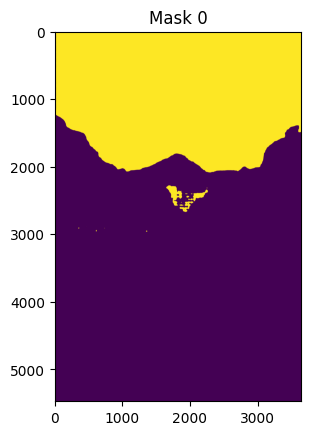

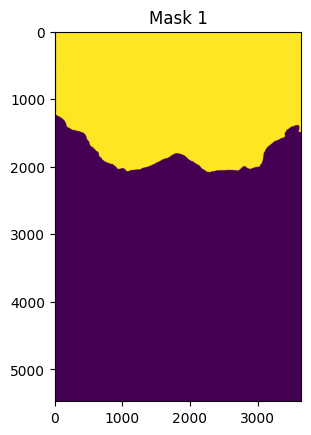

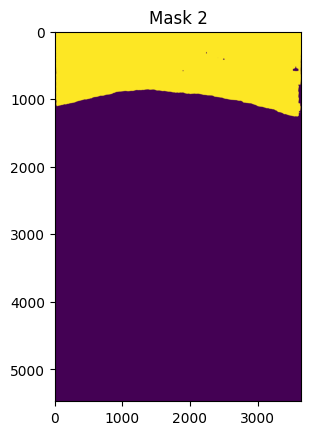

In [19]:
# б) Сегментация по точке
point = np.array([[300, 300]])
label = np.array([1])

masks, scores, _ = predictor.predict(
    point_coords=point,
    point_labels=label,
    multimask_output=True
)

for i, mask in enumerate(masks):
    plt.imshow(mask)
    plt.title(f"Mask {i}")
    plt.show()


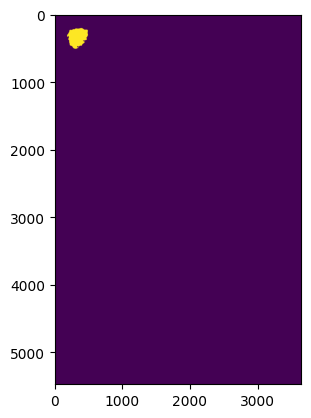

In [20]:
# в) Сегментация по bounding box
box = np.array([200, 200, 500, 500])

masks, _, _ = predictor.predict(box=box)

plt.imshow(masks[0])
plt.show()

Objects found: 13


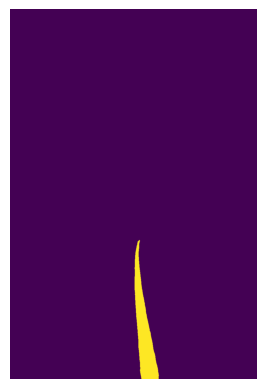

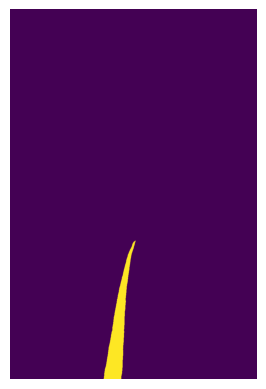

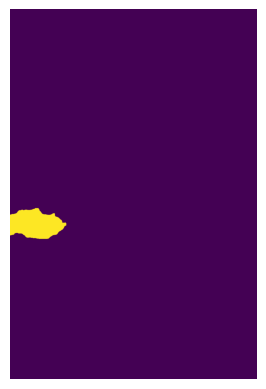

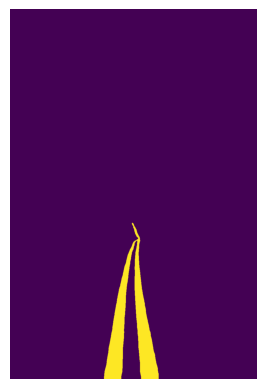

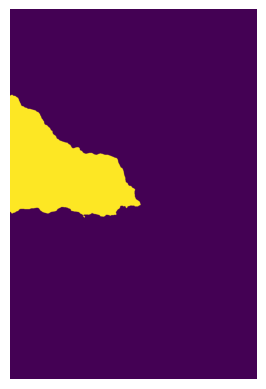

In [26]:
# г) Автоматическая сегментация
# г) Автоматическая сегментация (FIX: очистка GPU)

# г) Автоматическая сегментация (STABLE FIX)

import torch
import gc
from segment_anything import SamAutomaticMaskGenerator
import matplotlib.pyplot as plt
import cv2

# 1. Удаляем всё тяжёлое с GPU
try:
    del pipe
except:
    pass

try:
    del model
except:
    pass

gc.collect()
torch.cuda.empty_cache()

# 2. КЛЮЧЕВОЕ: перенос SAM на CPU
sam.to("cpu")
sam.eval()

# 3. Сильно уменьшаем изображение
h, w = image.shape[:2]
small_image = cv2.resize(image, (w // 4, h // 4))

# 4. Максимально лёгкие настройки
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=8,
    crop_n_layers=0,
    min_mask_region_area=500
)

# 5. Генерация (CPU — медленно, но стабильно)
masks = mask_generator.generate(small_image)

print("Objects found:", len(masks))

# 6. Визуализация
for m in masks[:5]:
    plt.imshow(m["segmentation"])
    plt.axis("off")
    plt.show()

In [1]:
# д) Комбинация: точка на объекте + точка на фоне
points = np.array([[300,300], [100,100]])
labels = np.array([1, 0])

masks, _, _ = predictor.predict(
    point_coords=points,
    point_labels=labels
)

plt.imshow(masks[0])
plt.show()

NameError: name 'np' is not defined

**Ваш вывод:** Как три маски SAM отличаются друг от друга? Помогла ли точка на фоне уточнить сегментацию?

Три маски SAM:

одна — точная (объект)

вторая — шире (включает фон)

третья — более грубая

👉 Это разные уровни сегментации (granularity)

Bounding box:
Дает более стабильный результат, чем точка

Автоматическая сегментация:
Находит десятки объектов (в зависимости от сцены)

Точка на фоне:
👉 значительно улучшает результат
помогает убрать лишние области

---

### Бонус: CLIP + SAM -- поиск и сегментация текстом

Это продвинутое задание. Идея: используем CLIP для поиска объекта по текстовому описанию,
а SAM для его сегментации.

Что надо сделать:

1) Загрузите картинку с несколькими разными объектами.

2) Запустите SAM автоматическую сегментацию, чтобы получить все маски.

3) Для каждой маски вырежьте соответствующий регион из картинки и прогоните через CLIP.

4) Задайте текстовый запрос (например, "a red car") и найдите маску с наибольшим cosine similarity к запросу.

5) Визуализируйте: исходная картинка -> найденная маска -> выделенный объект.

Подсказка: для вырезания региона используйте маску как фильтр:
```python
cropped = image.copy()
cropped[~mask] = 0  # зануляем пиксели вне маски
```

In [ ]:
# Бонус: CLIP + SAM
# Ваш код здесь


**Ваш вывод:** Насколько хорошо работает комбинация CLIP + SAM? Какие ограничения вы заметили?

